In [1]:
%pip install keras-tuner
%pip install tensorboard
%pip install scikit-learn
%pip install seaborn

     |████████████████████████████████| 129 kB 1.2 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt
from tensorflow.keras.callbacks import TensorBoard
import datetime
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import base64
from PIL import Image
import io
import logging
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pymongo
import os
from tensorflow.keras.utils import plot_model
import gc
from tqdm import tqdm
import tensorflow as tf
from numba import cuda
import time
import logging

In [6]:
# Function to load and merge data
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Function to process images in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalize to values between 0 and 1
        return image_array
    except Exception as e:
        logging.error(f"Error processing image: {e}")
        return None

# Function to prepare images and labels
def prepare_images(df, example_user_id):
    images = []
    labels = []
    for _, row in df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Load and prepare data
merged_df = load_data()
example_user_id = 'benutzername_1'
user_1_df = merged_df[merged_df['username'] == example_user_id].sample(n=1000, random_state=42)
other_users_df = merged_df[merged_df['username'] != example_user_id].sample(n=2000, random_state=42)
combined_df = pd.concat([user_1_df, other_users_df])
X, y = prepare_images(combined_df, example_user_id)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure data type compatibility
X_train = X_train.astype('float32')
y_train = y_train.astype('float32')
X_test = X_test.astype('float32')
y_test = y_test.astype('float32')

In [7]:
def build_model(hp):
    model = Sequential()
    model.add(Conv2D(filters=hp.Int('conv_1_filter', min_value=32, max_value=128, step=16),
                     kernel_size=hp.Choice('conv_1_kernel', values=[3, 5]),
                     activation='relu',
                     input_shape=(224, 224, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(filters=hp.Int('conv_2_filter', min_value=32, max_value=128, step=16),
                     kernel_size=hp.Choice('conv_2_kernel', values=[3, 5]),
                     activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=16), activation='relu'))
    model.add(Dropout(rate=hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

# Hyperparameter Tuning
from kerastuner.tuners import RandomSearch

tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='cnn_tuning'
)

# TensorBoard Callback
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test), callbacks=[tensorboard_callback])

Reloading Tuner from my_dir/cnn_tuning/tuner0.json


/tmp/ipykernel_29/3023223106.py:24: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


In [8]:
# Beste Hyperparameter und Modellarchitektur
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

print(best_hyperparameters.values)

# Speichern des besten Modells
best_model.save('best_model.h5')

2025-01-23 12:17:55.286218: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-23 12:17:55.314736: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-23 12:17:55.315027: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

{'conv_1_filter': 64, 'conv_1_kernel': 3, 'conv_2_filter': 128, 'conv_2_kernel': 3, 'dense_units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001}


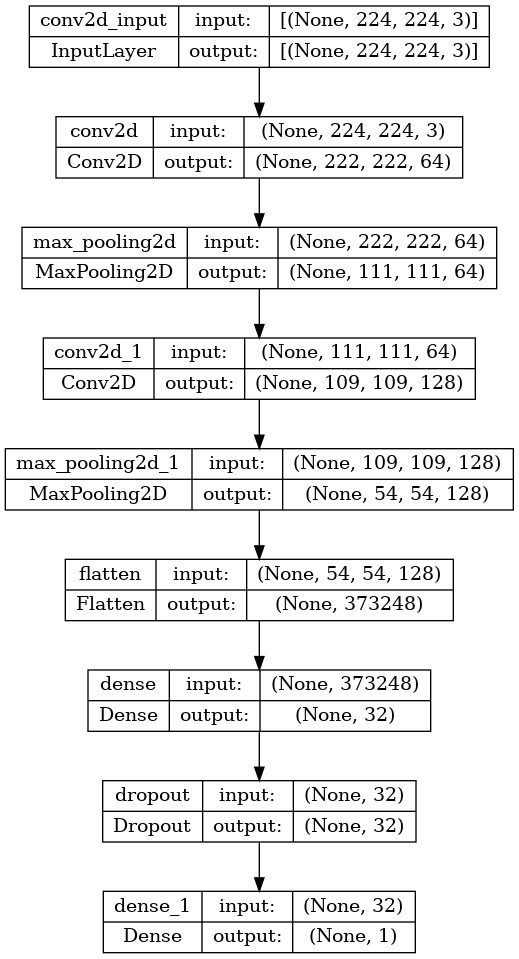

In [9]:
# Visualisierung der Modellarchitektur
from tensorflow.keras.utils import plot_model
plot_model(best_model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [10]:
# Starten Sie TensorBoard
%load_ext tensorboard
%tensorboard --logdir logs/fit

2025-01-23 12:19:19.008379: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8906


14/19 [=====================>........] - ETA: 0s

2025-01-23 12:19:19.280121: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


19/19 [==============================] - 1s 15ms/step
Evaluation Metrics:
Accuracy: 0.3617
Precision: 0.3617
Recall: 1.0000
F1 Score: 0.5312
ROC AUC: 0.5338


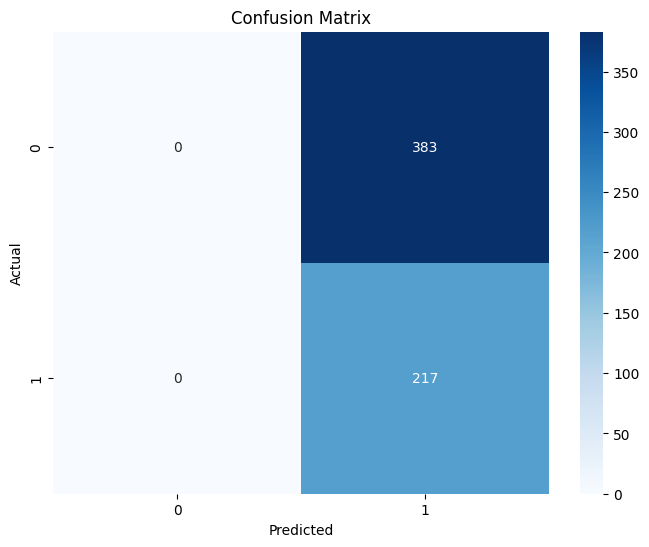

Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       383
         1.0       0.36      1.00      0.53       217

    accuracy                           0.36       600
   macro avg       0.18      0.50      0.27       600
weighted avg       0.13      0.36      0.19       600



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


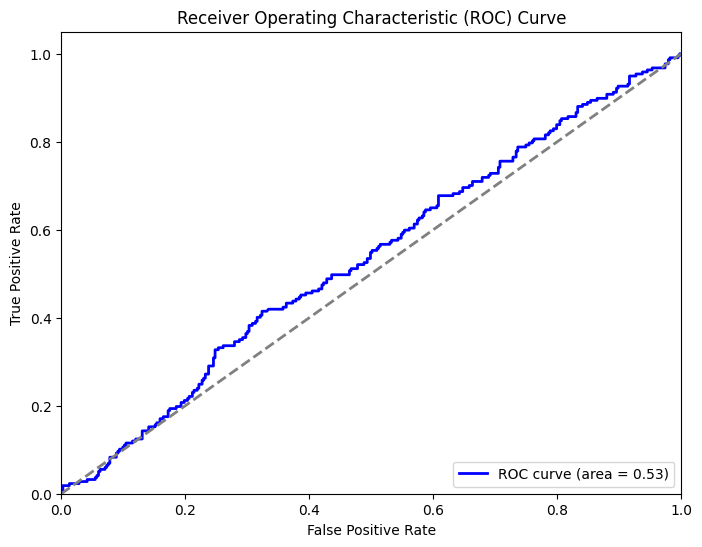

In [11]:
def evaluate_model(y_true, y_pred_labels, y_pred_probs):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred_labels),
        'Precision': precision_score(y_true, y_pred_labels),
        'Recall': recall_score(y_true, y_pred_labels),
        'F1 Score': f1_score(y_true, y_pred_labels),
        'ROC AUC': roc_auc_score(y_true, y_pred_probs)
    }
    return metrics

y_pred = best_model.predict(X_test)
y_pred_labels = (y_pred > 0.5).astype(int)

metrics = evaluate_model(y_test, y_pred_labels, y_pred)
print("Evaluation Metrics:")
for metric, value in metrics.items():
    if value is not None:
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: None")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
class_report = classification_report(y_test, y_pred_labels)
print("Classification Report:\n", class_report)

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()